<a href="https://colab.research.google.com/github/Prarthana-06/CODESOFT/blob/main/Movie_Genre_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>



---



In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import warnings
warnings.filterwarnings('ignore')

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay
)
from sklearn.preprocessing import LabelEncoder

print(' All imports successful!')

 All imports successful!


In [3]:
from google.colab import files
uploaded = files.upload()
print('Uploaded files:', list(uploaded.keys()))

Saving test_data_solution.txt to test_data_solution.txt
Saving train_data.txt to train_data (1).txt
Saving test_data.txt to test_data.txt
Saving description.txt to description.txt
Uploaded files: ['test_data_solution.txt', 'train_data (1).txt', 'test_data.txt', 'description.txt']


In [4]:
def load_train(filepath):
    """Load train_data.txt: ID ::: TITLE ::: GENRE ::: DESCRIPTION"""
    rows = []
    with open(filepath, 'r', encoding='utf-8', errors='replace') as f:
        for line in f:
            parts = line.strip().split(' ::: ')
            if len(parts) == 4:
                rows.append({
                    'id':          parts[0].strip(),
                    'title':       parts[1].strip(),
                    'genre':       parts[2].strip().lower(),
                    'description': parts[3].strip()
                })
    return pd.DataFrame(rows)


def load_test(filepath):
    """Load test_data.txt: ID ::: TITLE ::: DESCRIPTION"""
    rows = []
    with open(filepath, 'r', encoding='utf-8', errors='replace') as f:
        for line in f:
            parts = line.strip().split(' ::: ')
            if len(parts) == 3:
                rows.append({
                    'id':          parts[0].strip(),
                    'title':       parts[1].strip(),
                    'description': parts[2].strip()
                })
    return pd.DataFrame(rows)


def load_solution(filepath):
    """Load test_data_solution.txt: ID ::: TITLE ::: GENRE ::: DESCRIPTION"""
    return load_train(filepath)   # same format as train


train_df    = load_train('train_data.txt')
test_df     = load_test('test_data.txt')
solution_df = load_solution('test_data_solution.txt')

print(f'Train rows   : {len(train_df):,}')
print(f'Test rows    : {len(test_df):,}')
print(f'Solution rows: {len(solution_df):,}')
train_df.head(3)

Train rows   : 54,214
Test rows    : 54,200
Solution rows: 54,200


,id,title,genre,description
0,1,Oscar et la dame rose (2009),drama,Listening in to a conversation between his doc...
1,2,Cupid (1997),thriller,A brother and sister with a past incestuous re...
2,3,"Young, Wild and Wonderful (1980)",adult,As the bus empties the students for their fiel...


In [5]:
print('Missing values in train:')
print(train_df.isnull().sum())
print(f'\nUnique genres: {train_df["genre"].nunique()}')
print('\nTop 10 genres:')
print(train_df['genre'].value_counts().head(10))

Missing values in train:
id             0
title          0
genre          0
description    0
dtype: int64

Unique genres: 27

Top 10 genres:
genre
drama          13613
documentary    13096
comedy          7447
short           5073
horror          2204
thriller        1591
action          1315
western         1032
reality-tv       884
family           784
Name: count, dtype: int64


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

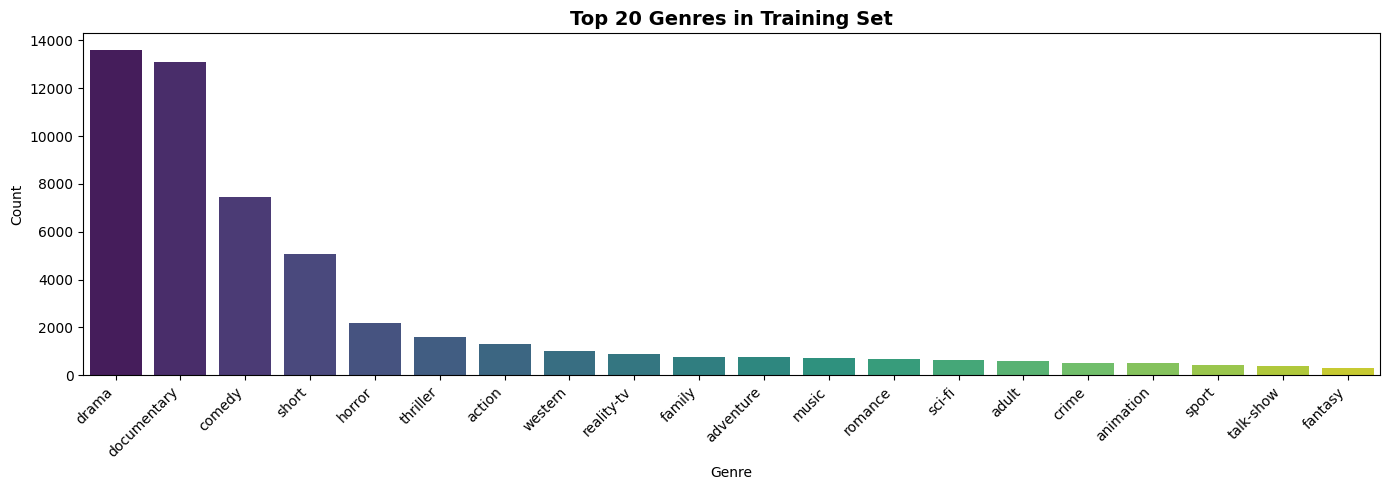

In [6]:

top_genres = train_df['genre'].value_counts().head(20)

fig, ax = plt.subplots(figsize=(14, 5))
sns.barplot(x=top_genres.index, y=top_genres.values, palette='viridis', ax=ax)
ax.set_title('Top 20 Genres in Training Set', fontsize=14, fontweight='bold')
ax.set_xlabel('Genre')
ax.set_ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('genre_distribution.png', dpi=150)
plt.show()

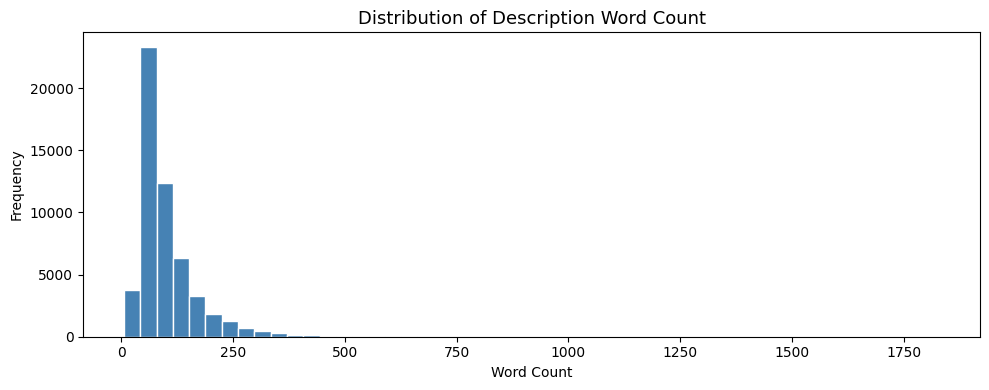

Mean words : 102
Median words: 79


In [7]:

train_df['desc_len'] = train_df['description'].str.split().str.len()

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(train_df['desc_len'], bins=50, color='steelblue', edgecolor='white')
ax.set_title('Distribution of Description Word Count', fontsize=13)
ax.set_xlabel('Word Count')
ax.set_ylabel('Frequency')
plt.tight_layout()
plt.show()

print(f"Mean words : {train_df['desc_len'].mean():.0f}")
print(f"Median words: {train_df['desc_len'].median():.0f}")

In [8]:
def clean_text(text):
    """Lowercase, remove punctuation/numbers, collapse whitespace."""
    text = text.lower()
    text = re.sub(r'[^a-z\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

train_df['clean_desc'] = train_df['description'].apply(clean_text)
test_df['clean_desc']  = test_df['description'].apply(clean_text)
solution_df['clean_desc'] = solution_df['description'].apply(clean_text)

print('Sample cleaned description:')
print(train_df['clean_desc'].iloc[0][:200])

Sample cleaned description:
listening in to a conversation between his doctor and parents year old oscar learns what nobody has the courage to tell him he only has a few weeks to live furious he refuses to speak to anyone except


In [9]:

X_train = train_df['clean_desc'].values
y_train = train_df['genre'].values

X_test  = test_df['clean_desc'].values
y_test  = solution_df['genre'].values

print(f'Training samples : {len(X_train):,}')
print(f'Test samples     : {len(X_test):,}')
print(f'Unique genres    : {len(set(y_train))}')

Training samples : 54,214
Test samples     : 54,200
Unique genres    : 27


In [10]:

TFIDF_PARAMS = dict(
    max_features=60_000,
    ngram_range=(1, 2),
    sublinear_tf=True,
    min_df=2,
    stop_words='english'
)

models = {
    'Naive Bayes': Pipeline([
        ('tfidf', TfidfVectorizer(**TFIDF_PARAMS)),
        ('clf',   MultinomialNB(alpha=0.1))
    ]),
    'Logistic Regression': Pipeline([
        ('tfidf', TfidfVectorizer(**TFIDF_PARAMS)),
        ('clf',   LogisticRegression(max_iter=1000, C=5, solver='saga', n_jobs=-1))
    ]),
    'Linear SVM': Pipeline([
        ('tfidf', TfidfVectorizer(**TFIDF_PARAMS)),
        ('clf',   LinearSVC(C=0.5, max_iter=2000))
    ]),
}

results = {}

for name, pipeline in models.items():
    print(f'Training: {name} ...', end=' ', flush=True)
    pipeline.fit(X_train, y_train)
    preds   = pipeline.predict(X_test)
    acc     = accuracy_score(y_test, preds)
    results[name] = {'pipeline': pipeline, 'preds': preds, 'accuracy': acc}
    print(f'  Accuracy = {acc:.4f} ({acc*100:.2f}%)')

Training: Naive Bayes ...   Accuracy = 0.5626 (56.26%)
Training: Logistic Regression ...   Accuracy = 0.6043 (60.43%)
Training: Linear SVM ...   Accuracy = 0.6038 (60.38%)


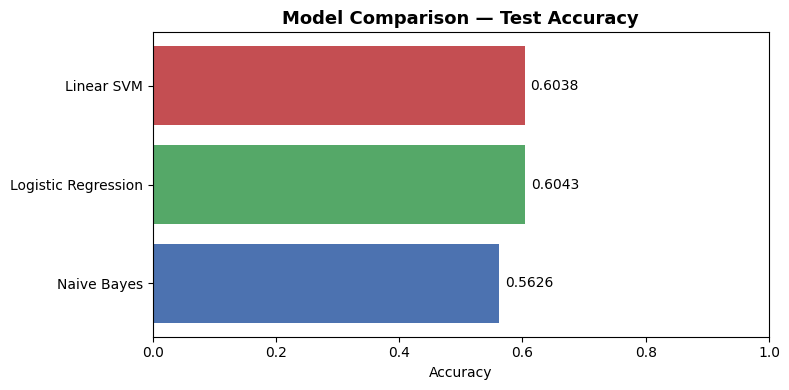

In [11]:

names  = list(results.keys())
accs   = [results[n]['accuracy'] for n in names]

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.barh(names, accs, color=['#4C72B0', '#55A868', '#C44E52'])
ax.bar_label(bars, labels=[f'{a:.4f}' for a in accs], padding=4)
ax.set_xlim(0, 1)
ax.set_xlabel('Accuracy')
ax.set_title('Model Comparison — Test Accuracy', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150)
plt.show()

In [12]:

best_name = max(results, key=lambda k: results[k]['accuracy'])
best      = results[best_name]
print(f' Best model: {best_name}  (accuracy = {best["accuracy"]:.4f})')

 Best model: Logistic Regression  (accuracy = 0.6043)


In [13]:

print(f'Classification Report — {best_name}\n')
print(classification_report(y_test, best['preds']))

Classification Report — Logistic Regression

              precision    recall  f1-score   support

      action       0.49      0.36      0.42      1314
       adult       0.69      0.36      0.48       590
   adventure       0.59      0.22      0.33       775
   animation       0.54      0.11      0.18       498
   biography       0.00      0.00      0.00       264
      comedy       0.56      0.61      0.58      7446
       crime       0.32      0.06      0.11       505
 documentary       0.70      0.84      0.77     13096
       drama       0.57      0.77      0.65     13612
      family       0.51      0.15      0.23       783
     fantasy       0.41      0.08      0.13       322
   game-show       0.87      0.57      0.69       193
     history       0.38      0.01      0.02       243
      horror       0.66      0.62      0.64      2204
       music       0.67      0.50      0.57       731
     musical       0.36      0.05      0.09       276
     mystery       0.38      0.03   

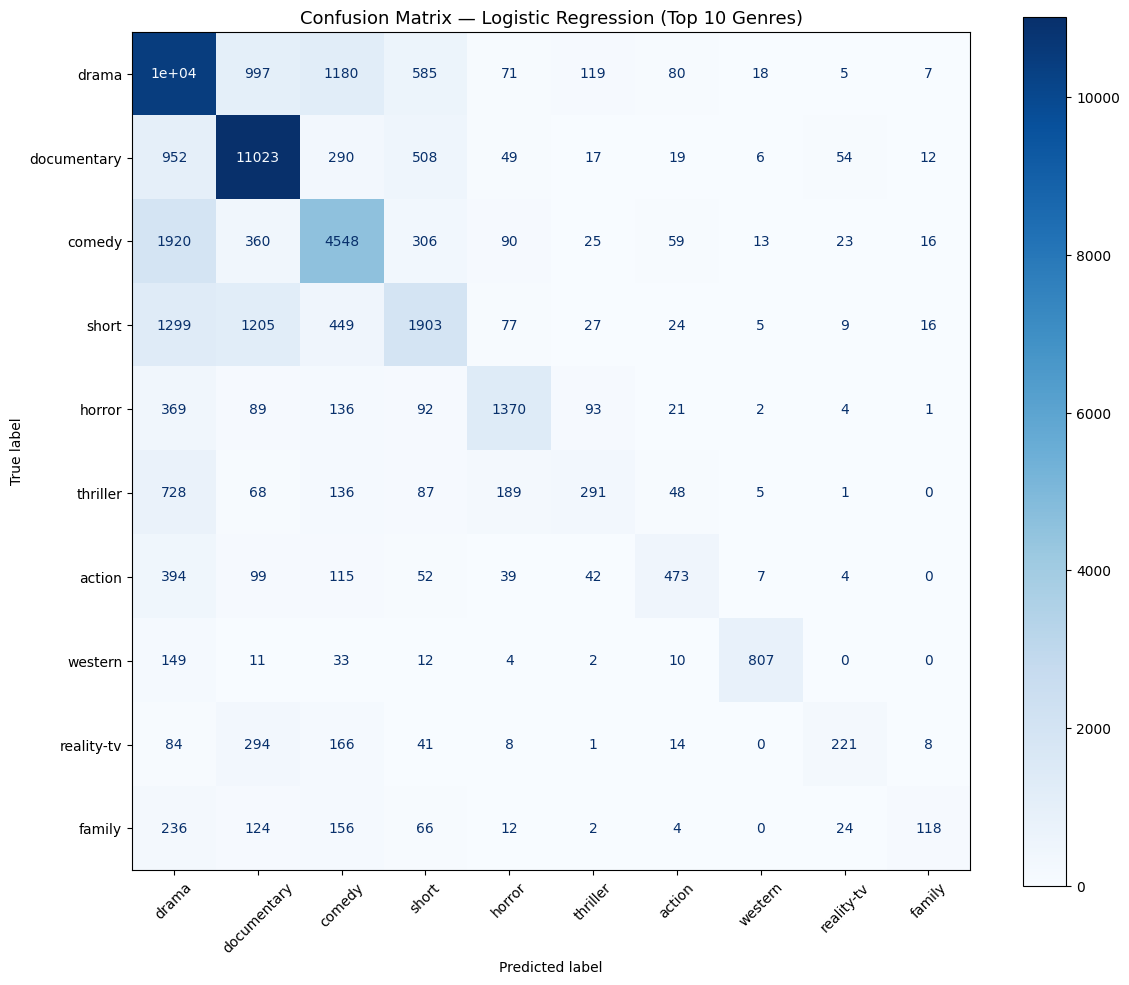

In [14]:

top10 = train_df['genre'].value_counts().head(10).index.tolist()

mask_true = pd.Series(y_test).isin(top10)
y_test_top10  = pd.Series(y_test)[mask_true].values
y_pred_top10  = pd.Series(best['preds'])[mask_true].values

cm = confusion_matrix(y_test_top10, y_pred_top10, labels=top10)

fig, ax = plt.subplots(figsize=(12, 10))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=top10)
disp.plot(ax=ax, cmap='Blues', colorbar=True, xticks_rotation=45)
ax.set_title(f'Confusion Matrix — {best_name} (Top 10 Genres)', fontsize=13)
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()

In [15]:
submission = test_df[['id', 'title']].copy()
submission['predicted_genre'] = best['preds']
submission['true_genre']      = y_test
submission['correct']         = submission['predicted_genre'] == submission['true_genre']

submission.to_csv('predictions.csv', index=False)
print(f'Saved predictions.csv  ({len(submission):,} rows)')
submission.head(10)

Saved predictions.csv  (54,200 rows)


,id,title,predicted_genre,true_genre,correct
0,1,Edgar's Lunch (1998),comedy,thriller,False
1,2,La guerra de papá (1977),drama,comedy,False
2,3,Off the Beaten Track (2010),documentary,documentary,True
3,4,Meu Amigo Hindu (2015),drama,drama,True
4,5,Er nu zhai (1955),drama,drama,True
5,6,Riddle Room (2016),drama,horror,False
6,7,L'amica (1969),drama,drama,True
7,8,Ina Mina Dika (1989),comedy,comedy,True
8,9,Equinox Special: Britain's Tornados (2005),documentary,documentary,True
9,10,Press (2011),documentary,drama,False


In [16]:

from google.colab import files
files.download('predictions.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [19]:
def predict_genre(plot_summary: str, model_name: str = None) -> None:
    """Predict genre from a custom plot description."""
    model_name = model_name or best_name
    pipeline   = results[model_name]['pipeline']
    cleaned    = clean_text(plot_summary)
    genre      = pipeline.predict([cleaned])[0]


    clf = pipeline.named_steps['clf']
    tfidf_vec = pipeline.named_steps['tfidf']
    X = tfidf_vec.transform([cleaned])

    if hasattr(clf, 'predict_proba'):
        probs = clf.predict_proba(X)[0]
        top3_idx = np.argsort(probs)[::-1][:3]
        classes  = clf.classes_
        top3 = [(classes[i], probs[i]) for i in top3_idx]
    else:

        scores   = clf.decision_function(X)[0]
        top3_idx = np.argsort(scores)[::-1][:3]
        classes  = clf.classes_
        top3 = [(classes[i], scores[i]) for i in top3_idx]

    print(f'Model       : {model_name}')
    print(f'Prediction  :  {genre.upper()}')
    print('\nTop-3 predictions:')
    for g, s in top3:
        bar = '█' * int(30 * (s / top3[0][1])) if top3[0][1] > 0 else ''
        print(f'  {g:20s}  {bar}  ({s:.3f})')



my_plot = """
A group of astronauts embark on a dangerous mission beyond the known galaxy.
When their ship is damaged by a mysterious alien signal, they must fight for survival
while uncovering an ancient extraterrestrial civilization that could change humanity forever.
"""

predict_genre(my_plot)

Model       : Logistic Regression
Prediction  :  SCI-FI

Top-3 predictions:
  sci-fi                ██████████████████████████████  (0.938)
  action                  (0.018)
  adventure               (0.013)


In [20]:

another_plot = """
Two rival chefs compete in the world's most prestigious cooking tournament.
Behind the kitchen banter hides a blossoming romance and a secret family recipe
that could decide the winner.
"""

predict_genre(another_plot)

Model       : Logistic Regression
Prediction  :  COMEDY

Top-3 predictions:
  comedy                ██████████████████████████████  (0.541)
  drama                 ███████  (0.130)
  reality-tv            █████  (0.094)


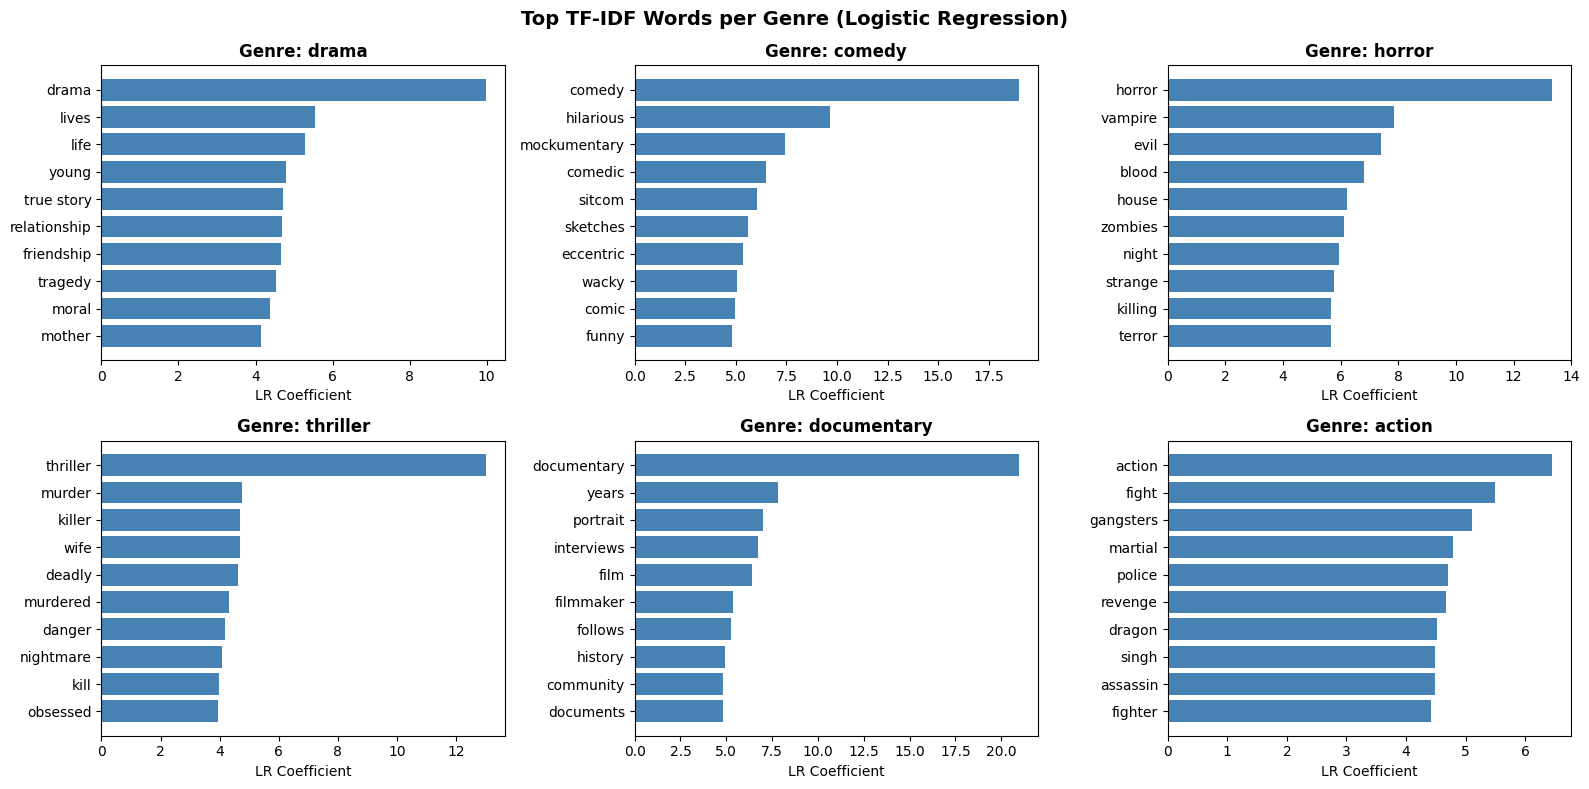

In [21]:

lr_pipeline = results['Logistic Regression']['pipeline']
tfidf       = lr_pipeline.named_steps['tfidf']
lr_clf      = lr_pipeline.named_steps['clf']
feature_names = np.array(tfidf.get_feature_names_out())

N_WORDS = 10
genres_to_show = ['drama', 'comedy', 'horror', 'thriller', 'documentary', 'action']

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()

for ax, genre in zip(axes, genres_to_show):
    if genre not in lr_clf.classes_:
        ax.set_visible(False)
        continue
    idx    = list(lr_clf.classes_).index(genre)
    coef   = lr_clf.coef_[idx]
    top_idx = np.argsort(coef)[::-1][:N_WORDS]
    words  = feature_names[top_idx]
    vals   = coef[top_idx]

    ax.barh(words[::-1], vals[::-1], color='steelblue')
    ax.set_title(f'Genre: {genre}', fontweight='bold')
    ax.set_xlabel('LR Coefficient')

plt.suptitle('Top TF-IDF Words per Genre (Logistic Regression)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150)
plt.show()